# 18 — Laya routes the heterogeneous front-ends (OCR / VLA / JEPA)

Notebook 15 built the union `S(t) = S_ocr ∪ S_vla ∪ S_jepa` from three
capture-first front-ends. Notebooks 16–17 put Rust Laya in the loop as a
router over the three LLMs. This notebook combines the two: **Laya decides,
at each step, which front-end should handle the query**, and that front-end's
next captured frame joins the union.

Here the options are genuinely different worlds — read text, move the robot,
predict the scene — so Laya's calibrated probabilities should finally
separate. The loop runs entirely on CPU (no GPU): ewm-scene + the Rust Laya
daemon + the three pre-captured JSONLs.

In [1]:
import os, sys, json

import numpy as np

EWM_SM = "/home/alexmy/SGS/SGS_lib/fractal_manifold_gen2/ewm-state-machine"
sys.path.insert(0, EWM_SM)

from trainer import (
    EwmScene,
    LayaAdapter,
    run_open_loop_from_streams,
    run_jev_loop_from_streams,
)

CAP = "/home/alexmy/.cache/ewm-hetero"
WORK = "/home/alexmy/.cache/ewm-hetero-laya18"
os.makedirs(WORK, exist_ok=True)

ewm = EwmScene()
print("ewm-scene:", ewm.bin)

ewm-scene: /home/alexmy/SGS/SGS_lib/fractal_manifold_gen2/ewm-state-machine/target/debug/ewm-scene


In [2]:
def load_capture(name):
    frames = []
    with open(f"{CAP}/capture_{name}.jsonl") as fh:
        for line in fh:
            frames.append(json.loads(line))
    return [f["tokens"] for f in frames]

streams = {
    "ocr": load_capture("ocr"),
    "vla": load_capture("vla"),
    "jepa": load_capture("jepa"),
}
T = 24
streams["vla"] = streams["vla"] + [streams["vla"][-1]] * (T - len(streams["vla"]))
for name, fr in streams.items():
    print(f"{name:5s} frames={len(fr):2d}  unique={len({t for f in fr for t in f})}")

ocr   frames=24  unique=14
vla   frames=24  unique=4
jepa  frames=24  unique=238


In [3]:
QUERIES = [
    "What does the camera see right now?",
    "Which robot action should come next?",
    "What text is on the page?",
    "Predict the next scene in the video.",
    "Verify the document content.",
    "What happens next in the scene?",
    "Read the label on the object.",
    "Plan the next movement.",
]

In [4]:
open_result = run_open_loop_from_streams(ewm, streams, WORK)
print("IICA (union == pyramid union):", open_result.same_union)
print("BSS trajectory:", open_result.M_ol.shape)
print("frontends:", open_result.names)

IICA (union == pyramid union): True
BSS trajectory: (24, 3)
frontends: ['ocr', 'vla', 'jepa']


In [5]:
laya = LayaAdapter()
print("Laya mode:", "mock" if laya.mock else "real rust/candle")

options = {
    "ocr": "the query asks to read or verify text from a page or document",
    "vla": "the query asks which physical action the robot should take next",
    "jepa": "the query asks what happens next in a video or scene",
}
instructions = "Which front-end should handle this query?"

laya_result = run_jev_loop_from_streams(
    ewm, streams, laya, open_result.frame_path, QUERIES, WORK, T=T,
    instructions=instructions, options=options,
    confidence_floor=0.10, fallback="jepa", ingest_decision=True,
)

decisions = laya_result.decision_log
print()
print("decision distribution (Laya's choice before gating):")
for name in open_result.names:
    n = sum(1 for d in decisions if d.decision == name)
    print(f"  {name:5s} {n:2d} steps")
print("gated to fallback:", sum(laya_result.gated_log), "of", len(laya_result.gated_log))
print("mean confidence:", round(float(np.mean([d.confidence for d in decisions])), 4))
print("mean aux noul (needs_memory):",
      round(float(np.mean([d.aux.get("needs_memory", 0.0) for d in decisions])), 4))

last_frame = json.loads(open(laya_result.union_path).readlines()[-1])
jev_tokens = [t for t in last_frame["tokens"] if t.startswith("jev_")]
print("jev_* decision tokens in last union frame:", jev_tokens)
laya.close()

Laya mode: real rust/candle
t= 0 q=0  route=jepa    confidence=0.143  gated=False  mock=False
t= 4 q=4  route=ocr     confidence=0.264  gated=False  mock=False
t= 8 q=0  route=jepa    confidence=0.099  gated=True  mock=False
t=12 q=4  route=ocr     confidence=0.247  gated=False  mock=False
t=16 q=0  route=jepa    confidence=0.144  gated=False  mock=False
t=20 q=4  route=ocr     confidence=0.254  gated=False  mock=False
t=23 q=7  route=jepa    confidence=0.006  gated=True  mock=False

decision distribution (Laya's choice before gating):
  ocr    9 steps
  vla    2 steps
  jepa  13 steps
gated to fallback: 16 of 24
mean confidence: 0.1026
mean aux noul (needs_memory): 0.4811
jev_* decision tokens in last union frame: ['jev_choice_jepa', 'jev_conf_0', 'jev_p_ocr_28', 'jev_p_vla_35', 'jev_p_jepa_37', 'jev_needs_memory_4']


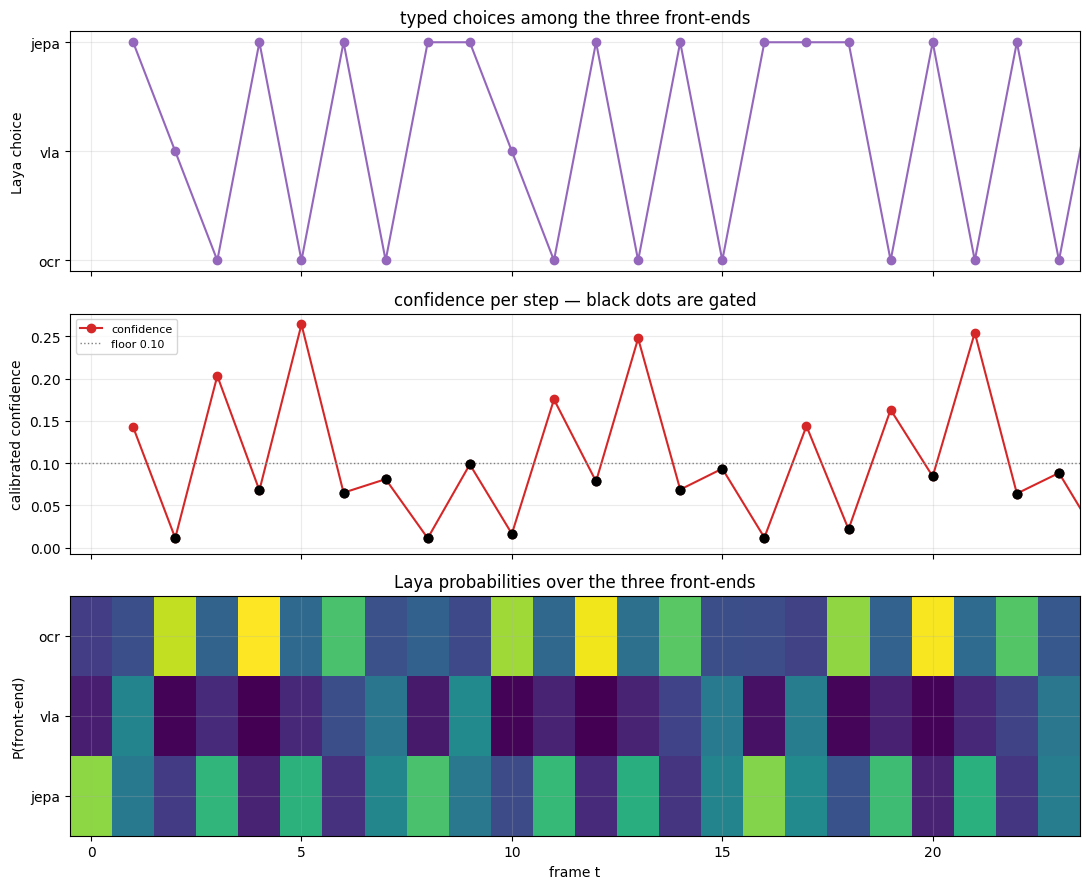

In [6]:
%matplotlib inline
import matplotlib.pyplot as plt

names = open_result.names
T = len(decisions)
t_axis = np.arange(1, T + 1)
conf = [d.confidence for d in decisions]
route_idx = [names.index(d.decision) for d in decisions]
gated = laya_result.gated_log

fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
axes[0].plot(t_axis, route_idx, "o-", color="tab:purple")
axes[0].set_yticks(range(len(names)), names)
axes[0].set_ylabel("Laya choice")
axes[0].set_title("typed choices among the three front-ends")
axes[0].grid(alpha=0.25)

axes[1].plot(t_axis, conf, "o-", color="tab:red", label="confidence")
axes[1].axhline(0.10, color="gray", ls=":", lw=1.0, label="floor 0.10")
for t, g in enumerate(gated):
    if g:
        axes[1].scatter([t_axis[t]], [conf[t]], color="black", zorder=5, s=40)
axes[1].set_ylabel("calibrated confidence")
axes[1].set_title("confidence per step — black dots are gated")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.25)

P = np.array([[d.probabilities.get(n, 0.0) for n in names] for d in decisions])
axes[2].imshow(P.T, aspect="auto", cmap="viridis", interpolation="nearest")
axes[2].set_yticks(range(len(names)), names)
axes[2].set_ylabel("P(front-end)")
axes[2].set_xlabel("frame t")
axes[2].set_title("Laya probabilities over the three front-ends")
axes[2].grid(alpha=0.25)

plt.tight_layout()
plt.savefig(f"{WORK}/laya_hetero_router.png", dpi=110)
plt.show()

## Summary

- The **same `DecisionRouter` seam** now routes across modalities: a typed
  decision model picks which front-end (OCR / VLA / JEPA) should handle the
  query, and the chosen front-end's captured frame joins the union `S(t)`.
- ewm-sm is still unchanged — only the router and the pre-captured streams
  differ from notebooks 13–17.
- With genuinely different options, Laya's probabilities separate far more
  than on the LLM-routing task; low-confidence steps still gate to the
  fallback.

Next: make this fully live — replace the pre-captured frames with live
front-end calls, and use the decision probabilities as extra soft-state
dimensions for the selector.